# 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import shap

d:\anaconda3\envs\ml-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Load Processed Data

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((88416, 24), (22105, 24), (88416, 1), (22105, 1))

# 3. Convert Target to Series

In [3]:
y_train = y_train['No-show']
y_test = y_test['No-show']
y_train.shape, y_test.shape

((88416,), (22105,))

# 4. Baseline Model — Logistic Regression

In [4]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

d:\anaconda3\envs\ml-env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# 4. Feature Scaling (Required for Logistic Regression)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Logistic Regression (with Scaled Data)

In [6]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# 6. Evaluate Logistic Regression

In [7]:
y_pred_log = log_reg.predict(X_test_scaled)
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.87      0.67      0.76     17642
           1       0.31      0.60      0.41      4463

    accuracy                           0.65     22105
   macro avg       0.59      0.63      0.58     22105
weighted avg       0.76      0.65      0.69     22105



# 7. Decision Tree

In [8]:
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


# 8. Evaluate Decision Tree

In [9]:
y_pred_dt = dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.92      0.52      0.67     17642
           1       0.31      0.83      0.45      4463

    accuracy                           0.59     22105
   macro avg       0.61      0.68      0.56     22105
weighted avg       0.80      0.59      0.62     22105



# 9. Model Comparison Summary

- Logistic Regression: Accuracy 0.65, Recall (no-show) 0.60, Precision (no-show) 0.31
- Decision Tree: Accuracy 0.59, Recall (no-show) 0.83, Precision (no-show) 0.31
- Decision Tree shows higher recall for the no-show class, which aligns better with the business goal of catching as many potential no-shows as possible.
- Both models suffer from low precision, indicating high false positive rate — this will be addressed with advanced models (Random Forest, XGBoost) in the next phase.

# 10. Random Forest

In [10]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 11. Evaluate Random Forest

In [11]:
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.56      0.70     17642
           1       0.32      0.80      0.45      4463

    accuracy                           0.61     22105
   macro avg       0.62      0.68      0.57     22105
weighted avg       0.80      0.61      0.65     22105



# 12. XGBoost

In [12]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=200, max_depth=6, scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


# 13. Evaluate XGBoost

In [13]:
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.90      0.63      0.74     17642
           1       0.33      0.71      0.45      4463

    accuracy                           0.65     22105
   macro avg       0.61      0.67      0.59     22105
weighted avg       0.78      0.65      0.68     22105



# 14. ROC-AUC Comparison

In [14]:
print("Logistic Regression:", roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:,1]))
print("Decision Tree:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))
print("Random Forest:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
print("XGBoost:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

Logistic Regression: 0.6788210222773384
Decision Tree: 0.7341955762026044
Random Forest: 0.7403455328566211
XGBoost: 0.7359220301155835


# 15. Final Model Selection

Random Forest is selected as the final model based on:
- Highest ROC-AUC score (0.740) among all models tested
- Strong recall (0.80) for the no-show class, aligning with the business priority of catching potential no-shows
- Tree-based structure enables clean SHAP explainability

# 16. Visual Model Comparison

In [15]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.65, 0.59, 0.61, 0.65],
    'Precision': [0.31, 0.31, 0.32, 0.33],
    'Recall': [0.60, 0.83, 0.80, 0.71],
    'F1_Score': [0.41, 0.45, 0.45, 0.45],
    'ROC_AUC': [0.679, 0.734, 0.740, 0.736]
})
model_comparison

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.65,0.31,0.60,0.41,0.679
1,Decision Tree,0.59,0.31,0.83,0.45,0.734
2,Random Forest,0.61,0.32,0.80,0.45,0.740
3,XGBoost,0.65,0.33,0.71,0.45,0.736


# 17. Model Comparison — Visual Chart

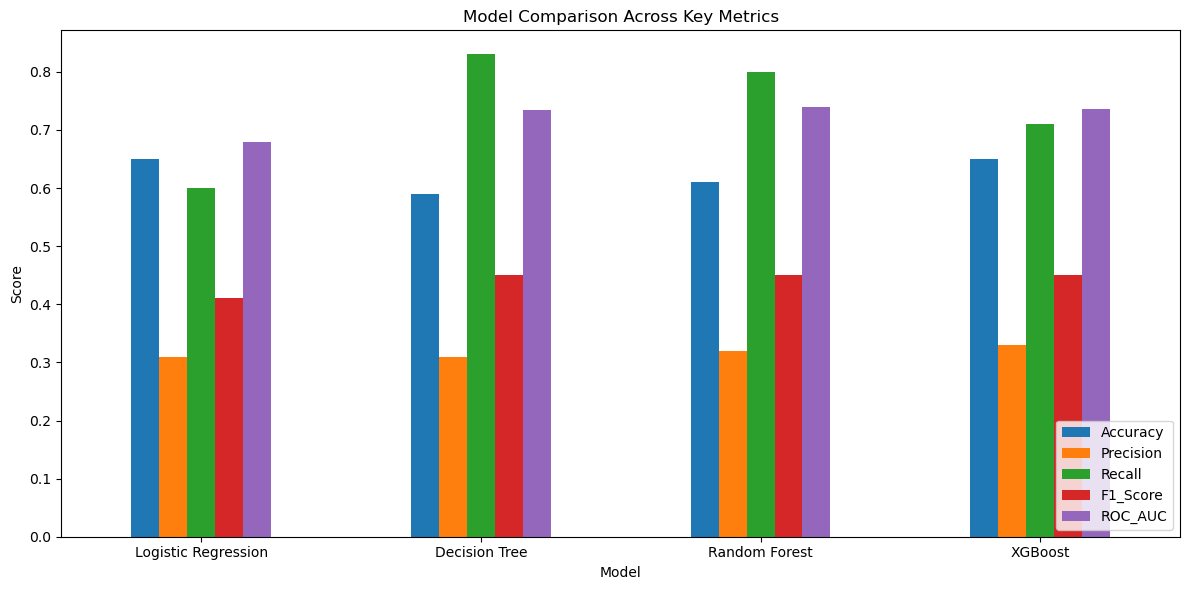

In [16]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']

fig, ax = plt.subplots(figsize=(12, 6))
model_comparison.set_index('Model')[metrics_to_plot].plot(kind='bar', ax=ax)
plt.title('Model Comparison Across Key Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
plt.close()

# 18. ROC-AUC Comparison Chart (Most Reliable Metric)

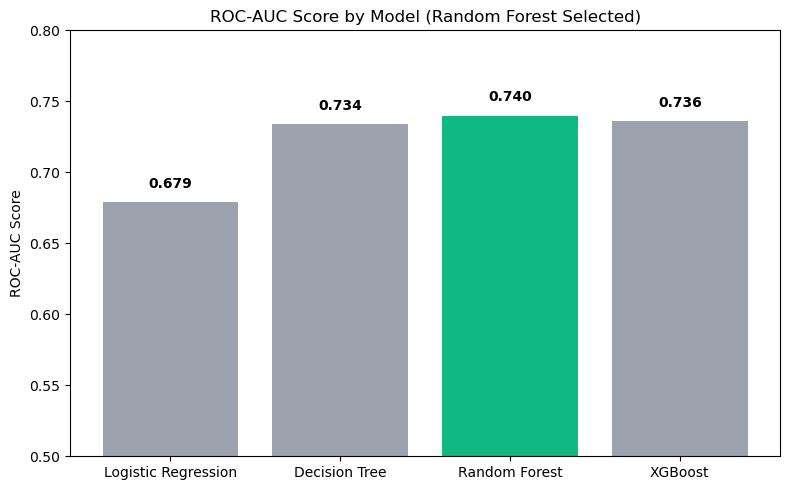

In [17]:
plt.figure(figsize=(8, 5))
colors = ['#9CA3AF' if model != 'Random Forest' else '#10B981' for model in model_comparison['Model']]
plt.bar(model_comparison['Model'], model_comparison['ROC_AUC'], color=colors)
plt.title('ROC-AUC Score by Model (Random Forest Selected)')
plt.ylabel('ROC-AUC Score')
plt.ylim(0.5, 0.8)
for i, v in enumerate(model_comparison['ROC_AUC']):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

# 19. Precision-Recall Trade-off (No-show Class)

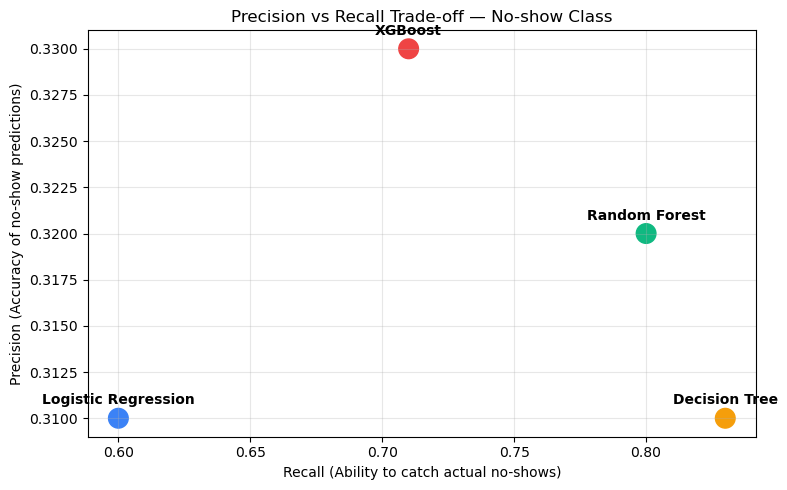

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(model_comparison['Recall'], model_comparison['Precision'], s=200, c=['#3B82F6', '#F59E0B', '#10B981', '#EF4444'])

for i, model in enumerate(model_comparison['Model']):
    plt.annotate(model, (model_comparison['Recall'][i], model_comparison['Precision'][i]),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold')

plt.title('Precision vs Recall Trade-off — No-show Class')
plt.xlabel('Recall (Ability to catch actual no-shows)')
plt.ylabel('Precision (Accuracy of no-show predictions)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

# 20. Save Final Model (Random Forest)

In [19]:
joblib.dump(rf, "../models/final_pipeline.joblib")

['../models/final_pipeline.joblib']

# 21. SHAP Explainability

In [20]:
X_sample = X_test.sample(500, random_state=42)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# 22. SHAP Summary Plot (Global Feature Importance)

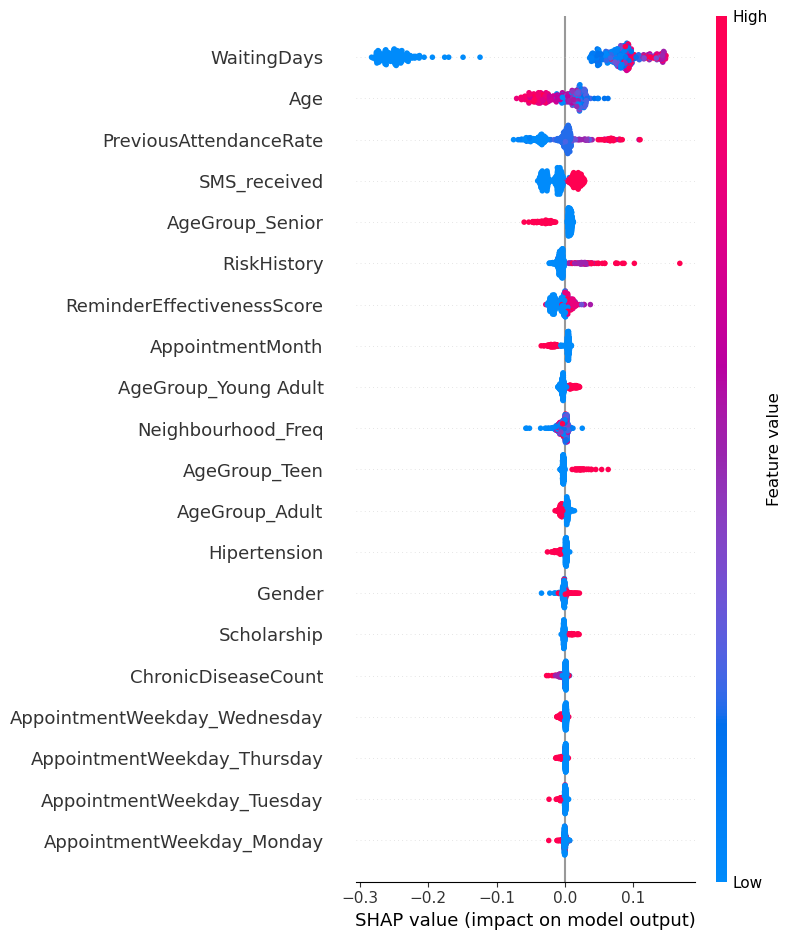

In [21]:
shap.summary_plot(shap_values[:, :, 1], X_sample)

# 23. SHAP Force Plot (Single Prediction Explanation)

In [22]:
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[0, :, 1], X_sample.iloc[0])